<div style="text-align: center; font-size: 40px; font-weight: bold;">
    Train Model Deeplabv3+ Architecture
</div>

# Libraries

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

2026-03-08 09:12:15.204430: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 09:12:15.210891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-08 09:12:15.218005: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-08 09:12:15.220341: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-08 09:12:15.226257: I tensorflow/core/platform/cpu_feature_guar

# Load Images

In [2]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


I0000 00:00:1772961136.351953     233 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772961136.374586     233 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772961136.375633     233 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [3]:
IMG_SIZE = (512, 512)

def load_image(img_path, mask_path):
    # ----- image -----
    img = tf.io.read_file(img_path)
    img = tf.image.decode_bmp(img, channels=3)   # gambar input RGB
    img = tf.image.resize(img, (IMG_SIZE[0], IMG_SIZE[1]))
    img = tf.cast(img, tf.float32) / 255.0

    # ----- mask -----
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_bmp(mask, channels=0)   # biarkan sesuai file
    mask = tf.image.resize(mask, (IMG_SIZE[0], IMG_SIZE[1]), method="nearest")
    
    # pastikan hanya 1 channel
    if tf.shape(mask)[-1] != 1:
        mask = tf.image.rgb_to_grayscale(mask)

    # ubah ke {0,1}
    mask = tf.cast(mask > 127, tf.float32)

    return img, mask

def make_dataset(img_dir, mask_dir, batch_size=4, shuffle=True):
    img_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=100)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset("project/Poreseg/Data_splitK4/train/images", "project/Poreseg/Data_splitK4/train/masks", batch_size=4)
val_ds   = make_dataset("project/Poreseg/Data_splitK4/valid/images", "project/Poreseg/Data_splitK4/valid/masks", batch_size=4, shuffle=False)

I0000 00:00:1772961136.425042     233 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772961136.426111     233 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772961136.427921     233 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772961136.532094     233 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

# Evaluation Metrics and Loss Functions

In [4]:
def iou_metric(y_true, y_pred, smooth: float = 1e-6) -> float:
    """
    Computes the Intersection over Union (IoU) metric.
    
    Args:
        y_true: Ground truth binary mask.
        y_pred: Predicted binary mask.
        smooth (float): Smoothing factor to avoid division by zero.
    
    Returns:
        float: IoU score.
    """
    y_pred = K.cast(y_pred > 0.5, dtype='float32')
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [5]:
def dice_loss(y_true, y_pred, smooth: float = 1e-6) -> tf.Tensor:
    """
    Computes the Dice loss for image segmentation.
    
    Args:
        y_true: Ground truth binary mask.
        y_pred: Predicted mask.
        smooth (float): Smoothing factor to avoid division by zero.
    
    Returns:
        tf.Tensor: Dice loss value.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    
    return 1 - ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))

# Modeling

In [6]:
def DeepLabV3Plus_ResNet50(input_shape=(512, 512, 3), num_classes=1):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Encoder feature maps
    high_level_feature = base_model.get_layer('conv4_block6_out').output  # stride 16
    low_level_feature = base_model.get_layer('conv2_block3_out').output   # stride 4

    # ASPP Module
    def ASPP(x):
        y1 = layers.Conv2D(256, 1, padding="same", use_bias=False)(x)
        y1 = layers.BatchNormalization()(y1)
        y1 = layers.Activation("relu")(y1)

        y2 = layers.Conv2D(256, 3, dilation_rate=12, padding="same", use_bias=False)(x)
        y2 = layers.BatchNormalization()(y2)
        y2 = layers.Activation("relu")(y2)

        y3 = layers.Conv2D(256, 3, dilation_rate=24, padding="same", use_bias=False)(x)
        y3 = layers.BatchNormalization()(y3)
        y3 = layers.Activation("relu")(y3)

        y4 = layers.Conv2D(256, 3, dilation_rate=36, padding="same", use_bias=False)(x)
        y4 = layers.BatchNormalization()(y4)
        y4 = layers.Activation("relu")(y4)

        y5 = layers.GlobalAveragePooling2D()(x)
        y5 = layers.Reshape((1, 1, y5.shape[-1]))(y5)
        y5 = layers.Conv2D(256, 1, padding="same", use_bias=False)(y5)
        y5 = layers.BatchNormalization()(y5)
        y5 = layers.Activation("relu")(y5)
        y5 = layers.UpSampling2D(size=(input_shape[0] // 16, input_shape[1] // 16),
                                 interpolation="bilinear")(y5)

        y = layers.Concatenate()([y1, y2, y3, y4, y5])
        y = layers.Conv2D(256, 1, padding="same", use_bias=False)(y)
        y = layers.BatchNormalization()(y)
        y = layers.Activation("relu")(y)
        y = layers.Dropout(0.5)(y)
        return y
    
    # Attention Block
    def attention_block(x, g, inter_channel):
        theta_x = layers.Conv2D(inter_channel, 1)(x)
        phi_g   = layers.Conv2D(inter_channel, 1)(g)
        add     = layers.Activation('relu')(layers.add([theta_x, phi_g]))
        psi     = layers.Conv2D(1, 1, activation='sigmoid')(add)
        return layers.multiply([x, psi])

    # Decoder
    x = ASPP(high_level_feature)
    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)

    low_level_feature = layers.Conv2D(48, 1, padding="same", use_bias=False)(low_level_feature)
    low_level_feature = layers.BatchNormalization()(low_level_feature)
    low_level_feature = layers.Activation("relu")(low_level_feature)

    # Attention Gate
    low_level_feature = attention_block(low_level_feature, x, 48)

    x = layers.Concatenate()([x, low_level_feature])
    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)
    outputs = layers.Conv2D(num_classes, 1, activation="sigmoid", dtype="float32")(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

model = DeepLabV3Plus_ResNet50()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 518, 518, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 256, 256, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 256, 256, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [7]:
# Kompilasi model
model.compile(optimizer="adam",
               loss=dice_loss,
               metrics=["accuracy", iou_metric])

# ======= Callbacks =======
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=5, 
                              min_lr=1e-6,
                              verbose=1)

model_checkpoint = ModelCheckpoint('project/Poreseg/Model/model_DeeplabV3+K4.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   verbose=1)

callbacks = [early_stop, lr_reduce, model_checkpoint]

# Training
history = model.fit(train_ds, 
                    validation_data=val_ds, 
                    epochs=100, 
                    callbacks=callbacks)

Epoch 1/100


2026-03-08 09:12:24.069636: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-08 09:12:29.733001: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1772961149.994006     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961150.007115     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961150.008411     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961150.021776     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961150.022656     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:17729611

  1/149 [..............................] - ETA: 48:13 - loss: 0.8298 - accuracy: 0.5082 - iou_metric: 0.0921

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1772961157.536958     313 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961157.537304     313 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961157.537735     313 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be 

  2/149 [..............................] - ETA: 4:07 - loss: 0.7880 - accuracy: 0.5369 - iou_metric: 0.1261 

...

149/149 [==============================] - 54s 232ms/step - loss: 0.3343 - accuracy: 0.9229 - iou_metric: 0.5269 - val_loss: 0.9937 - val_accuracy: 0.8994 - val_iou_metric: 9.8178e-12 - lr: 0.0010
Epoch 2/100
148/149 [============================>.] - ETA: 0s - loss: 0.2647 - accuracy: 0.9467 - iou_metric: 0.5945

W0000 00:00:1772961209.665085     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.673439     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.675388     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.677325     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.679332     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.681360     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.683442     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.686704     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.690363     309 gp

149/149 [==============================] - ETA: 0s - loss: 0.2646 - accuracy: 0.9467 - iou_metric: 0.5948

W0000 00:00:1772961209.872128     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.878643     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.882715     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.887666     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.898546     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.905034     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.909150     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.913592     309 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1772961209.930827     309 gp


Epoch 2: val_loss improved from 0.99368 to 0.94597, saving model to project/Poreseg/Model/model_DeeplabV3+K4.keras
149/149 [==============================] - 21s 141ms/step - loss: 0.2646 - accuracy: 0.9467 - iou_metric: 0.5948 - val_loss: 0.9460 - val_accuracy: 0.8994 - val_iou_metric: 9.8178e-12 - lr: 0.0010
Epoch 3/100
149/149 [==============================] - ETA: 0s - loss: 0.2499 - accuracy: 0.9497 - iou_metric: 0.6113
Epoch 3: val_loss did not improve from 0.94597
149/149 [==============================] - 19s 126ms/step - loss: 0.2499 - accuracy: 0.9497 - iou_metric: 0.6113 - val_loss: 0.9999 - val_accuracy: 0.8994 - val_iou_metric: 9.8178e-12 - lr: 0.0010
Epoch 4/100
149/149 [==============================] - ETA: 0s - loss: 0.2419 - accuracy: 0.9513 - iou_metric: 0.6202
Epoch 4: val_loss did not improve from 0.94597
149/149 [==============================] - 19s 126ms/step - loss: 0.2419 - accuracy: 0.9513 - iou_metric: 0.6202 - val_loss: 0.9999 - val_accuracy: 0.8994 - val

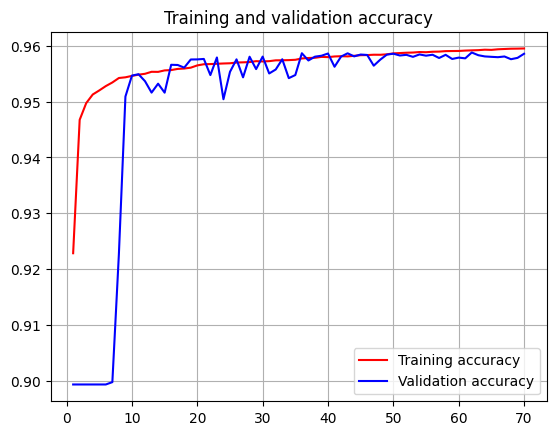

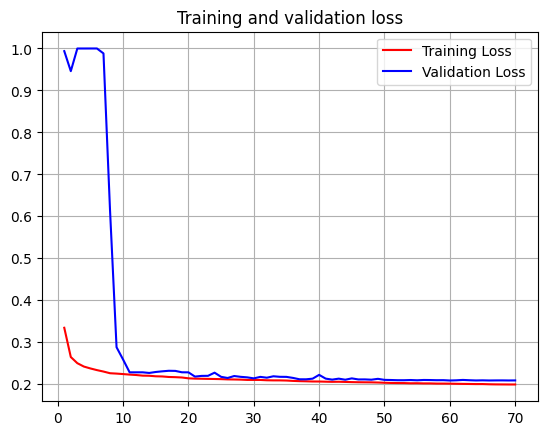

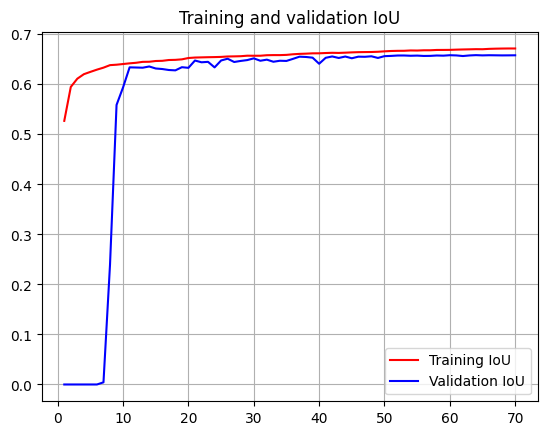

In [8]:
# Extract data from history.history
epochs = range(1, len(history.history['loss']) + 1)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
iou = history.history['iou_metric']
val_iou = history.history['val_iou_metric']

# Plotting Training and Validation Accuracy
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.grid(True)
plt.show()  # Display accuracy plot

# Plotting Training and Validation Loss
plt.figure()
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()  # Display loss plot

# Plotting Training and Validation IoU
plt.figure()
plt.plot(epochs, iou, 'r', label='Training IoU')
plt.plot(epochs, val_iou, 'b', label='Validation IoU')
plt.title('Training and validation IoU')
plt.legend()
plt.grid(True)
plt.show()  # Display IoU plot

In [9]:
# Hitung rata-rata untuk setiap metrik
avg_acc = np.mean(history.history['accuracy'])
avg_val_acc = np.mean(history.history['val_accuracy'])

avg_loss = np.mean(history.history['loss'])
avg_val_loss = np.mean(history.history['val_loss'])

avg_iou = np.mean(history.history['iou_metric'])
avg_val_iou = np.mean(history.history['val_iou_metric'])

# Cetak hasil rata-rata
print("=== Average Results Training ===")
print(f"Average Training Accuracy   : {avg_acc:.4f}")
print(f"Average Validation Accuracy : {avg_val_acc:.4f}")
print(f"Average Training Loss       : {avg_loss:.4f}")
print(f"Average Validation Loss     : {avg_val_loss:.4f}")
print(f"Average Training IoU        : {avg_iou:.4f}")
print(f"Average Validation IoU      : {avg_val_iou:.4f}")

=== Average Results Training ===
Average Training Accuracy   : 0.9566
Average Validation Accuracy : 0.9506
Average Training Loss       : 0.2130
Average Validation Loss     : 0.3003
Average Training IoU        : 0.6543
Average Validation IoU      : 0.5766
